# Electric Vehicle Sales Analysis (India)

### Objective
Analyze EV sales trends across states, vehicle categories, and months
to identify growth patterns and business insights.

### Tools Used
- SQL (PostgreSQL)
- Python (Pandas, Matplotlib)
- Jupyter Notebook

In [2]:
import pandas as pd
import numpy as np


df = pd.read_csv('EV_Dataset.csv', index_col=False)


In [4]:
df.head()

,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity
0,2014.0,jan,1/1/2014,Andhra Pradesh,ADAPTED VEHICLE,Others,Others,0.0
1,2014.0,jan,1/1/2014,Andhra Pradesh,AGRICULTURAL TRACTOR,Others,Others,0.0
2,2014.0,jan,1/1/2014,Andhra Pradesh,AMBULANCE,Others,Others,0.0
3,2014.0,jan,1/1/2014,Andhra Pradesh,ARTICULATED VEHICLE,Others,Others,0.0
4,2014.0,jan,1/1/2014,Andhra Pradesh,BUS,Bus,Bus,0.0


In [66]:
df.isnull().sum().sort_values(ascending=False)

year                 0
month_name           0
date                 0
state                0
vehicle_class        0
vehicle_category     0
vehicle_type         0
ev_sales_quantity    0
dtype: int64

In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               96845 non-null  float64
 1   month_name         96845 non-null  str    
 2   date               96845 non-null  str    
 3   state              96845 non-null  str    
 4   vehicle_class      96845 non-null  str    
 5   vehicle_category   96845 non-null  str    
 6   vehicle_type       96845 non-null  str    
 7   ev_sales_quantity  96845 non-null  float64
dtypes: float64(2), str(6)
memory usage: 5.9 MB


In [62]:
df['year'] = pd.to_numeric(df['year'], errors='coerce')

df = df.dropna(subset=['year']) 

df['year'] = df['year'].astype(int)

In [51]:
df['date'] = pd.to_datetime(df['date'])

In [60]:
df['ev_sales_quantity'] = df['ev_sales_quantity'].astype(int)

In [52]:
#Convert these words to the category dtype. It stores the unique string once and uses a small integer point for the rest. This can reduce memory(RAM) usage by 80-90%

cols_to_cat = ['state', 'vehicle_class', 'vehicle_category', 'vehicle_type']
df[cols_to_cat] = df[cols_to_cat].astype('category')

In [63]:
# as we can see the memory ussage drop
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   year               96845 non-null  int64         
 1   month_name         96845 non-null  str           
 2   date               96845 non-null  datetime64[us]
 3   state              96845 non-null  category      
 4   vehicle_class      96845 non-null  category      
 5   vehicle_category   96845 non-null  category      
 6   vehicle_type       96845 non-null  category      
 7   ev_sales_quantity  96845 non-null  int64         
dtypes: category(4), datetime64[us](1), int64(2), str(1)
memory usage: 3.3 MB


In [74]:
df.columns = [col.strip().replace(' ', '_').lower() for col in df.columns]

In [75]:
df.to_csv('cleaned_ev_data.csv', index=False)

In [77]:
df.dtypes

year                          int64
month_name                      str
date                 datetime64[us]
state                      category
vehicle_class              category
vehicle_category           category
vehicle_type               category
ev_sales_quantity             int64
dtype: object

## Business Problem

Government and automobile companies want to understand:

- Which months have highest EV adoption?
- Which vehicle categories dominate sales?
- Which states contribute most to EV growth?

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

yearly = pd.read_csv("./data/processed/yearly_sales.csv")
monthly = pd.read_csv("./data/processed/monthly_sales.csv")
state = pd.read_csv("./data/processed/state_sales.csv")
category = pd.read_csv("./data/processed/vehicle_category_sales.csv")



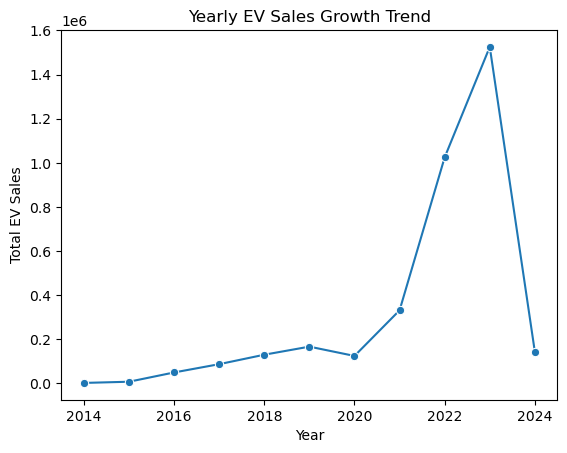

In [92]:
yearly = df.groupby("year")["ev_sales_quantity"].sum().reset_index()

sns.lineplot(data=yearly, x="year", y="ev_sales_quantity", marker="o")
plt.title("Yearly EV Sales Growth Trend")
plt.xlabel("Year")
plt.ylabel("Total EV Sales")
plt.show()

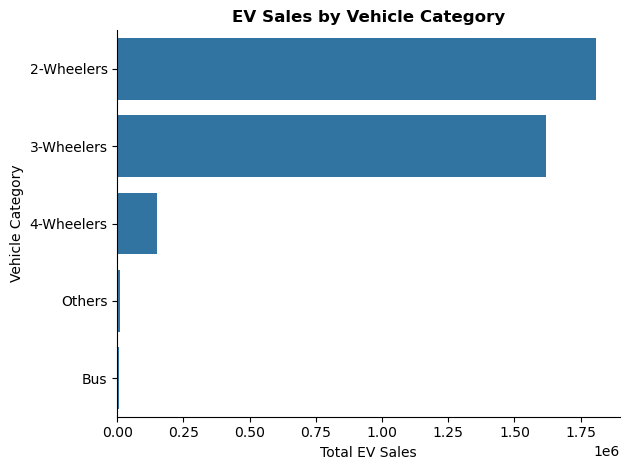

In [111]:

sns.barplot(
    data=category,
    x="total_sales",
    y="vehicle_category"
)

plt.title("EV Sales by Vehicle Category", weight="bold")
plt.xlabel("Total EV Sales")
plt.ylabel("Vehicle Category")

sns.despine()
plt.tight_layout()
plt.show()

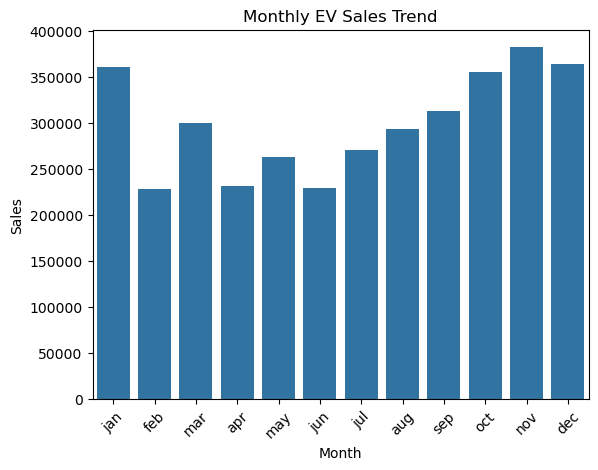

In [94]:
monthly = df.groupby("month_name")["ev_sales_quantity"].sum().reset_index()

order = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]

sns.barplot(data=monthly, x="month_name", y="ev_sales_quantity", order=order)
plt.title("Monthly EV Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

Where should companies invest?

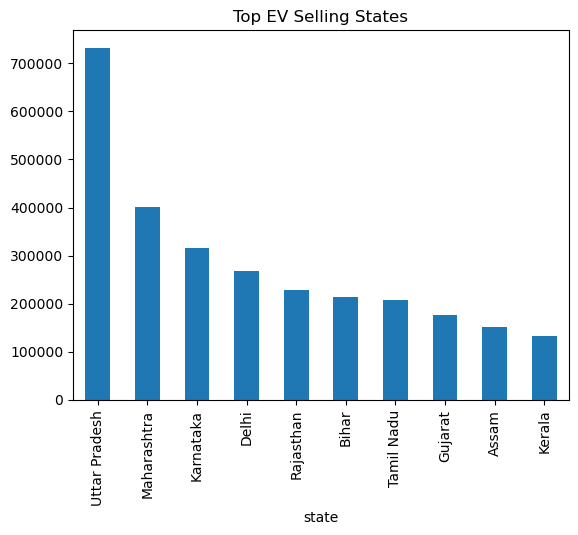

In [113]:
state_sales = df.groupby("state")["ev_sales_quantity"].sum().sort_values(ascending=False).head(10)
state_sales.plot(kind="bar")
plt.title("Top EV Selling States")
plt.show()

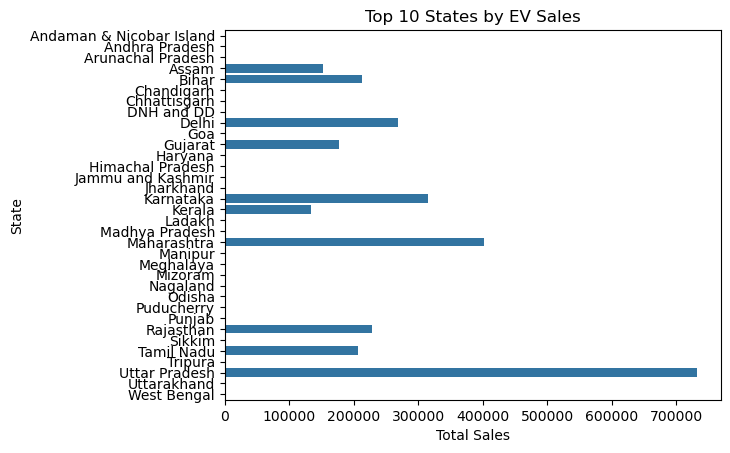

In [98]:
state_sales = (
    df.groupby("state")["ev_sales_quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

sns.barplot(x=state_sales.values, y=state_sales.index)
plt.title("Top 10 States by EV Sales")
plt.xlabel("Total Sales")
plt.ylabel("State")
plt.show()

In [ ]:
top_categories = (
    df.groupby("vehicle_category")["ev_sales_quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(6)
    .index
)

filtered_df = df[df["vehicle_category"].isin(top_categories)]

pivot = filtered_df.pivot_table(
    values="ev_sales_quantity",
    index="vehicle_category",
    columns="year",
    aggfunc="sum"
)

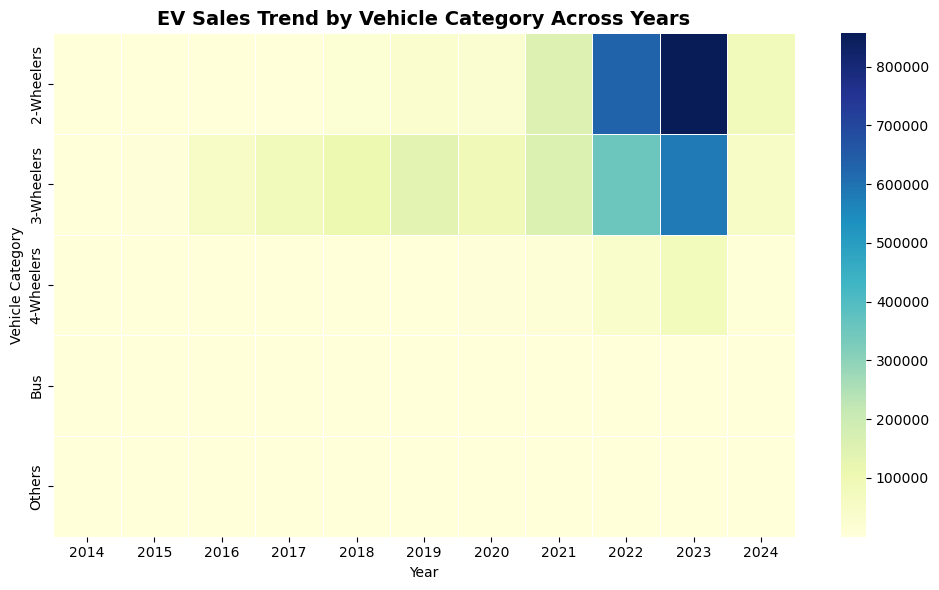

In [117]:
plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu",
    annot=False, 
    linewidths=0.5
)

plt.title("EV Sales Trend by Vehicle Category Across Years", 
          fontsize=14, weight="bold")

plt.xlabel("Year")
plt.ylabel("Vehicle Category")

plt.tight_layout()
plt.show()